# 02 · Dataset overview

ORD is a mix of a small number of very large datasets mined from patent literature (e.g. USPTO) and many smaller, hand-curated submissions. This notebook profiles what's loaded in the local database.

In [1]:
from dotenv import load_dotenv
import matplotlib.pyplot as plt

from ord_analysis.db import get_engine
from ord_analysis import queries

load_dotenv()
engine = get_engine()

## Datasets

In [2]:
datasets = queries.dataset_overview(engine)
print(datasets.shape)
datasets.head()

(53, 4)


,dataset_id,name,description,is_uspto
0,ord_dataset-0316886541d9435489859c2ad7edc863,Styrene Mizoroki-Heck,"Mizoroki-Heck couplings with Ni and Pd, 4 x 96...",False
1,ord_dataset-10b940e7982c4622b1e1ac879394aba6,Imidazopyridines dataset,Data form a 3 component reaction approach towa...,False
2,ord_dataset-0c75d67751634f0594b24b9f498b77c2,Shields Arylation,"Reactions from Shields, B.J., Stevens, J., Li,...",False
3,ord_dataset-00005539a1e04c809a9a78647bea649c,750 AstraZeneca ELN dataset,This dataset includes 750 Buchwald-Hartwig rea...,False
4,ord_dataset-172039a759a440219a68af62d203b79b,Cernak miniaturized N-alkylation with BOC depr...,Miniaturized N-alkylation and BOC deprotection...,False


In [3]:
datasets["is_uspto"].value_counts()

is_uspto
False    52
True      1
Name: count, dtype: int64

## Reaction counts by dataset

In [4]:
counts = queries.reaction_counts_by_dataset(engine)
counts.head()

,dataset_id,is_uspto,count
0,ord_dataset-00005539a1e04c809a9a78647bea649c,False,750
1,ord_dataset-0316886541d9435489859c2ad7edc863,False,96
2,ord_dataset-0c75d67751634f0594b24b9f498b77c2,False,256
3,ord_dataset-10b940e7982c4622b1e1ac879394aba6,False,384
4,ord_dataset-1158e351757f315b93cbcbe7bc55f38e,True,1771032


datasets missing record_created: 49 / 53


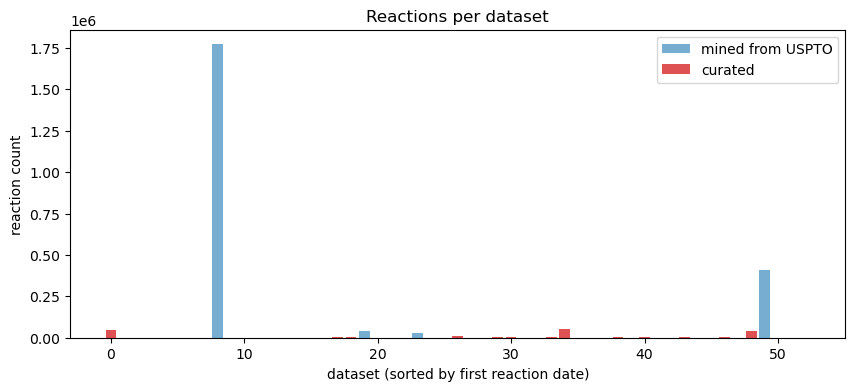

In [5]:
first_dates = queries.dataset_first_reaction_dates(engine)
print(f"datasets missing record_created: {first_dates['record_created'].isna().sum()} / {len(first_dates)}")

pivot = counts.pivot_table(index="dataset_id", columns="is_uspto", values="count", fill_value=0)
pivot = pivot.join(first_dates.set_index("dataset_id"))
pivot = pivot.sort_values("record_created", ascending=True, na_position="last")

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(pivot)), pivot.get(True, 0), color="tab:blue", alpha=0.6, label="mined from USPTO")
ax.bar(range(len(pivot)), pivot.get(False, 0), color="tab:red", alpha=0.8, label="curated")
ax.set_title("Reactions per dataset")
ax.set_xlabel("dataset (sorted by first reaction date)")
ax.set_ylabel("reaction count")
ax.legend()
plt.show()

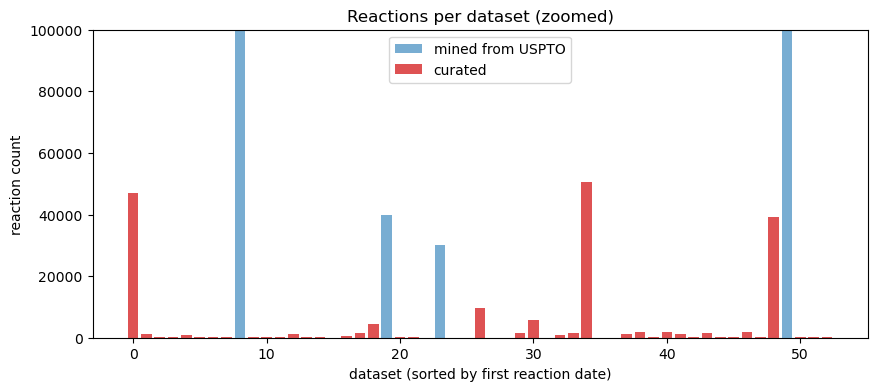

In [6]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(pivot)), pivot.get(True, 0), color="tab:blue", alpha=0.6, label="mined from USPTO")
ax.bar(range(len(pivot)), pivot.get(False, 0), color="tab:red", alpha=0.8, label="curated")
ax.set_title("Reactions per dataset (zoomed)")
ax.set_xlabel("dataset (sorted by first reaction date)")
ax.set_ylabel("reaction count")
ax.set_ylim(0, 100_000)
ax.legend()
plt.show()